### Overview

We implement a supervised classification workflow to classify the prepared composite into multiple landcover classes. We will train a Random Forest model using the training samples and predict the landcover class for all pixels in the composite.



### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install rioxarray dask['distributed'] scikit-learn \
        xarray-spatial

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask.array as da
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio
import rioxarray as rxr
import xarray as xr
from pyproj import Transformer
from sklearn.ensemble import RandomForestClassifier

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Load Multiband Composite

Load the multiband composite saved by the previous notebook in this section `01_preparing_composites.ipynb`. The composite contains 13 bands: 6 raw spectral bands (red, green, blue, nir, swir16, swir22), 5 precomputed indices (ndvi, ndbi, bsi, mndwi, ndwi) and 2 bands derived from a DEM (elevation, slope).

In [ ]:
multiband_composite_path = os.path.join(data_folder, 'multiband_composite.tif')
if not os.path.exists(multiband_composite_path):
    print(f'Composite file not found at {multiband_composite_path}.',
          'Using default composite.')
    multiband_composite_path = (
        'https://storage.googleapis.com/spatialthoughts-public-data'
        '/python-remote-sensing/multiband_composite.tif')

band_names = ['red', 'green', 'blue', 'nir', 'swir16', 'swir22',
              'ndvi', 'ndbi', 'bsi', 'mndwi', 'ndwi', 'elevation', 'slope']
composite_da = rxr.open_rasterio(
    multiband_composite_path,
    masked=True,
    chunks={'x': 1024, 'y': 1024},
)
composite_da = composite_da.assign_coords(band=band_names)
composite_da

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

aoi_gdf = gpd.read_file(aoi_filepath)
geometry = aoi_gdf.geometry.union_all()
geometry

### Load Training Data

The training data is a set of Ground Control Points (GCPs) — point features, each labeled with a land cover class. We load the GeoJSON file with GeoPandas.

In [ ]:
gcp_filepath = os.path.join(data_folder, 'gcps.geojson')

if not os.path.exists(gcp_filepath):
    print(f'GCP file not found at {gcp_filepath}. Using default GCPs.')
    gcp_filepath = (
        'https://storage.googleapis.com/spatialthoughts-public-data/'
        'python-remote-sensing/gcps.geojson'
    )

gcp_gdf = gpd.read_file(gcp_filepath)
gcp_gdf.head()

Let's check how many samples we have for each class.

In [ ]:
gcp_gdf['landcover'].value_counts(sort=False)

In [ ]:
class_colors = {
    0: '#cc6d8f', # Urban
    1: '#ffc107', # Bare
    2: '#1e88e5', # Water
    3: '#004d40', # Vegetation
}

class_names = {
    0: 'Urban',
    1: 'Bare',
    2: 'Water',
    3: 'Vegetation'
}

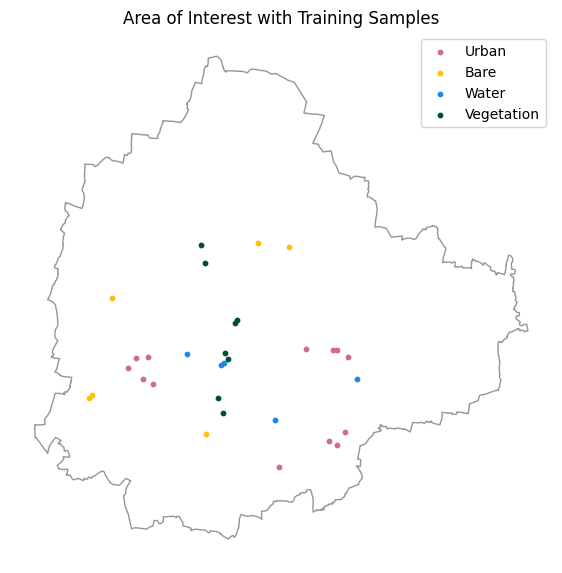

In [26]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7,7)
aoi_gdf.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#969696')

# Plot the GCPs
for class_label, group in gcp_gdf.groupby('landcover'):
    group.plot(
        ax=ax,
        color=class_colors.get(class_label, 'red'),
        markersize=10,
        label=class_names.get(class_label, f'Unknown Class {class_label}')
    )

ax.legend(loc='upper right')
ax.set_title('Area of Interest with Training Samples')
ax.set_axis_off()
plt.show()

### Normalize the Composite

Before we use the composit for building the classification model, we must normalize the values. Some bands such has elevation has very large values while others such as indices have small values. To ensure our model does not get biased, we must normalize the bands so they all have the values in the same range.

First we chunk the input so all the bands are in the same chunk.

In [ ]:
feature_da = composite_da.chunk({'band': -1, 'y': 1024, 'x': 1024})
feature_da

Scale the values so they are between 0 and 1. The scaling is done independently for each band by computing the minimum and maximum values in each band.

In [ ]:
band_min = feature_da.min(dim=['y', 'x'])
band_max = feature_da.max(dim=['y', 'x'])
feature_da = (feature_da - band_min) / (band_max - band_min)
feature_da

### Extract Features at Training Points

We reproject the GCP coordinates from WGS84 to the composite CRS, then use vectorized XArray selection to read the composite band values at each training point.

In [ ]:
gcp_gdf_reprojected = gcp_gdf.to_crs(feature_da.rio.crs)
x_coords = gcp_gdf_reprojected.geometry.x.values
y_coords = gcp_gdf_reprojected.geometry.y.values

Extract the pixel values.

In [ ]:
gcp_features = feature_da.sel(
    x=xr.DataArray(x_coords, dims='gcp_id'),
    y=xr.DataArray(y_coords, dims='gcp_id'),
    method='nearest'
)
gcp_features

We also need to have the `landcover` class values at each extraced sample for training the model.

In [ ]:
gcp_features = gcp_features.assign_coords(
    landcover=('gcp_id', gcp_gdf['landcover'].values))
gcp_features

In [ ]:
%%time
gcp_features = gcp_features.compute()

### Train a Classifier

We train a [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) on the extracted band values. Random Forest is robust to correlated features (spectral bands are often correlated) and provides feature importances that show which bands contributed most to the classification.

In [ ]:
X = gcp_features.values.T.astype(np.float64)  # (n_samples, n_bands)
y = gcp_features['landcover'].values

model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X, y)

In [ ]:
# Feature importances
importances = model.feature_importances_
for band, importance in sorted(zip(band_names, importances), key=lambda t: -t[1]):
    print(f'  {band:10s}: {importance:.3f}')

### Classify the Image

We apply the trained classifier to every pixel using [`dask.array.map_blocks`](https://docs.dask.org/en/stable/generated/dask.array.map_blocks.html). The `predict_block` function receives one `(bands, h, w)` tile, reshapes it to `(n_pixels, bands)`, skips NaN pixels, and returns a `(h, w)` label array. Setting `drop_axis=0` tells Dask that the band axis is consumed by the function.

In [ ]:
feature_dask = feature_da.data  # (bands, y, x)

def predict_block(block, model):
    bands, h, w = block.shape
    pixels = block.reshape(bands, -1).T.astype(np.float64)  # (n_pixels, bands)
    valid = ~np.isnan(pixels).any(axis=1)
    result = np.full(h * w, np.nan)
    if valid.any():
        result[valid] = model.predict(pixels[valid]).astype(float)
    return result.reshape(h, w)

predicted_2d = da.map_blocks(
    predict_block,
    feature_dask,
    model=model,
    dtype=np.float64,
    drop_axis=0,
)
classified = xr.DataArray(
    predicted_2d,
    coords={'y': feature_da.y, 'x': feature_da.x},
    dims=['y', 'x'],
    name='landcover'
).rio.write_crs(feature_da.rio.crs)
classified


In [ ]:
%%time
classified = classified.compute()

### Visualize the Classification

We build a discrete colormap from the class color dictionary and plot a downsampled preview.

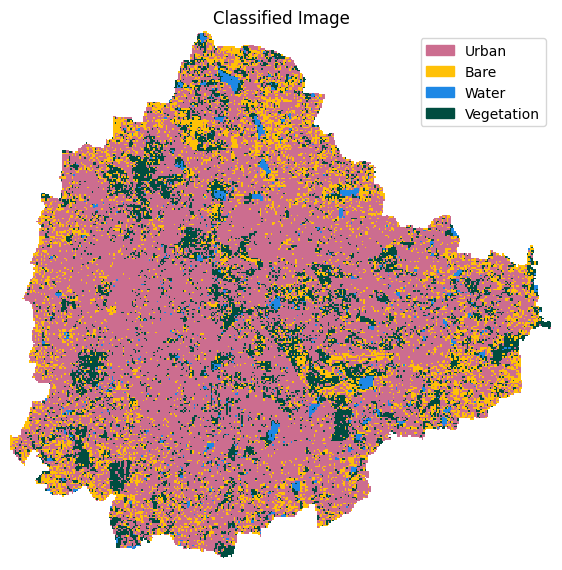

In [25]:
sorted_labels = sorted(class_colors.keys())
cmap = mcolors.ListedColormap([class_colors[c] for c in sorted_labels])
cmap.set_bad(alpha=0)
norm = mcolors.BoundaryNorm(
    [i - 0.5 for i in range(len(sorted_labels) + 1)], cmap.N)

preview = classified.rio.reproject(classified.rio.crs, resolution=100)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7, 7)
preview.plot.imshow(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
ax.legend(
    handles=[mpatches.Patch(
        color=class_colors[c],
        label=class_names[c]) for c in sorted_labels],
    loc='upper right'
)
ax.set_title(f'Classified Image')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

### Save Classified Image

Save the result as a Cloud-Optimized GeoTIFF to the configured output folder.

In [ ]:
def write_cog_with_colormap(data_array, output_path, color_table):
    if data_array.dtype != np.dtype('uint8'):
        raise TypeError(f'data_array must be uint8 for a color table to attach')

    # Write to a temp file, add color table, then convert to COG
    tmp_path = output_path + '.tmp.tif'
    data_array.rio.to_raster(tmp_path)

    with rasterio.open(tmp_path) as src:
        profile = src.profile.copy()
        profile['driver'] = 'COG'
        data = src.read(1)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)
            dst.write_colormap(1, color_table)

    os.remove(tmp_path)

In [ ]:
color_table = {
    label: tuple(int(c * 255) for c in mcolors.to_rgb(hex_color))
    for label, hex_color in class_colors.items()
}

classified_uint8 = (
    classified
    .fillna(255)
    .astype(np.uint8)
    .rio.write_nodata(255)
)

output_path = os.path.join(output_folder, 'classification.tif')
write_cog_with_colormap(classified_uint8, output_path, color_table)
print(f'Saved {output_path}')

### Exercise

Pixel-based classifications result in a lot of salt-and-pepper noise. You can apply a spatial filters to clean up the output. We will use a *Focal Majority* filter that passes a moving-window across the image and replaces the center pixel with the most frequently occuring value in that neighborhood. The code below implements the majority filter using the [`xrspatial.focal.apply()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.focal.apply.html#xrspatial.focal.apply) function.

In [ ]:
from xrspatial import convolution
from xrspatial.focal import apply
from xrspatial.utils import ngjit

# Creates a standard 3x3 square moving window
kernel = convolution.custom_kernel(np.ones((3, 3)))

# Define a custom 'Mode' function as there is no built-in mode operation
# This function calculates the majority class in a moving window
@ngjit
def custom_mode(kernel_data):
    # Flatten the moving window array
    flat = kernel_data.ravel()
    
    # Track the majority class manually (Numba-safe approach)
    counts = {}
    max_count = -1
    mode_val = flat[0]
    
    for val in flat:
        if np.isnan(val): 
            continue # Ignore missing data/boundaries
            
        # Count occurrences of each class
        if val in counts:
            counts[val] += 1
        else:
            counts[val] = 1
            
        # Track the highest count
        if counts[val] > max_count:
            max_count = counts[val]
            mode_val = val
            
    return mode_val


classified_smoothed = apply(classified, kernel, func=custom_mode)
